# **Фреймворки Python для анализа данных**

## Лабораторная работа №3. Изображения и видео

### Выполнила: Китаева Дарья М8О-102БВ-25

Импорты, нужные для корректной работы.

In [33]:
import cv2
import os
import matplotlib.pyplot as plt
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [34]:
import json
import torch
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
from datetime import datetime
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm import tqdm
import torch
from torchvision.ops import box_iou
from ultralytics import YOLO

In [20]:
!pip install torchmetrics

In [23]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.6 MB/s eta 0:00:00


Открываем видео и проверяем действительно ли оно открылось.

In [35]:
cap = cv2.VideoCapture('/content/drive/MyDrive/input.mp4')
if not cap.isOpened():
    print("Видео не открылось")

# **Извлечение и форматирование разметки**

Получаем информацию о видео: количество кадров в секунду, общее количество кадров, ширину, а также высоту.

In [36]:
fps = cap.get(cv2.CAP_PROP_FPS)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"Кадров в секунду: {fps}, всего кадров: {total}, ширина: {width}, высота: {height}")

Кадров в секунду: 30.0, всего кадров: 301, ширина: 1920, высота: 1080


Все кадры заносим в отдельный массив, а после с помощью библииотеки matplotlib выводим это изображение, чтобы удостовериться, что всё было правильно обработано.

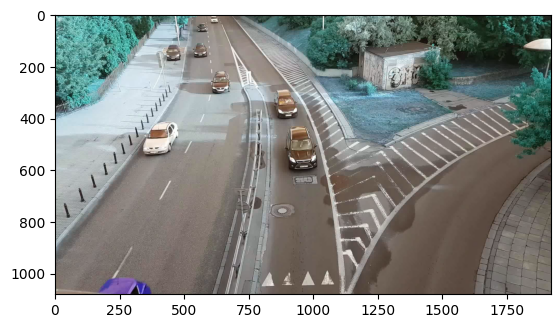

In [37]:
frames = []
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)
    frame_idx += 1

plt.imshow(frames[0])

Точно также обрабатываем видео output.mp4. Выводим первый кадр видео для того, чтобы убедиться в том, что всё действительно правильно открылось, а также, чтобы определить bbox'ы, обозначающие машины.

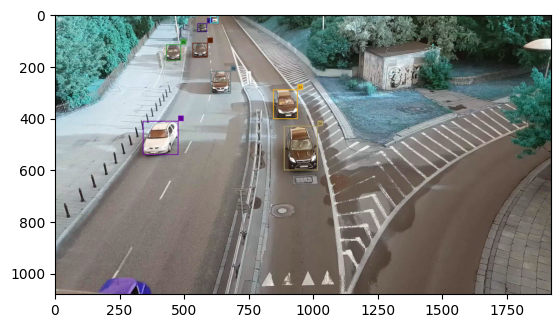

In [38]:
cap_out = cv2.VideoCapture('/content/drive/MyDrive/output.mp4')

frames_out = []
frame_idx_out = 0

while True:
    ret_out, frame_out = cap_out.read()
    if not ret_out:
        break
    frames_out.append(frame_out)
    frame_idx_out += 1

plt.imshow(frames_out[0])

Извлекаем контуры bbox'ов на первом кадре и выводим координаты нашего контура с его высотой и шириной, а также проверяем, чтобы на наше извлечение не попал лишний шум, для этого проверяем, что площадь нашего bbox'а не менее 20.

In [39]:
frame_in = frames[0]
frame_out = frames_out[0]

diff = cv2.absdiff(frame_out, frame_in)

gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if w * h > 20:
      print(f"bbox: x={x}, y={y}, w={w}, h={h}")

bbox: x=880, y=410, w=158, h=194
bbox: x=336, y=390, w=164, h=154
bbox: x=940, y=295, w=6, h=4
bbox: x=840, y=269, w=120, h=138
bbox: x=600, y=199, w=101, h=109
bbox: x=425, y=96, w=86, h=86
bbox: x=528, y=89, w=83, h=79
bbox: x=544, y=0, w=108, h=72


Как мы можем заметить нам было выведено 8 извлечённых bbox'ов, подсчитав те, что были у нас на первом кадре вручную можно сказать, что bbox'ы были извлечены верно, соответсвенно, можно проделать то же самое и для остальных кадров.

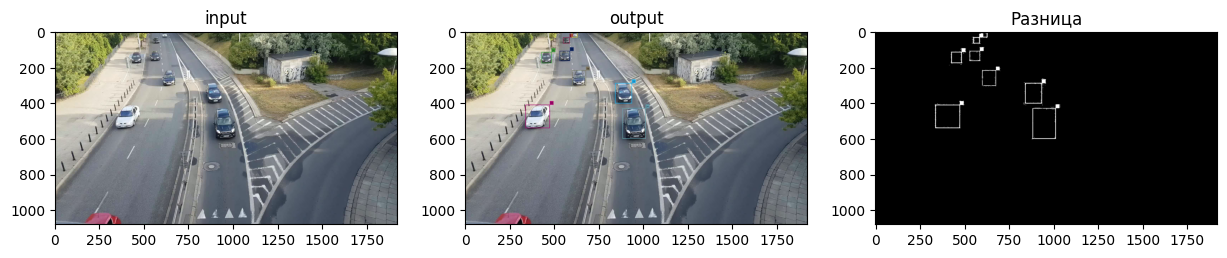

In [40]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(frame_in, cv2.COLOR_BGR2RGB))
plt.title('input')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(frame_out, cv2.COLOR_BGR2RGB))
plt.title('output')

plt.subplot(1, 3, 3)
plt.imshow(thresh, cmap='gray')
plt.title('Разница')

plt.show()

С помощью данных изображений ещё раз убеждаемся наглядно, что всё работает верно, так что можно приступить к извлечению контуров для остальных изображений.

In [41]:
all_annotations = []

for i, (frame_in, frame_out) in enumerate(zip(frames, frames_out)):
    diff = cv2.absdiff(frame_out, frame_in)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w * h > 20:
            all_annotations.append({
                'image_id': i,
                'bbox': [x, y, w, h],
                'area': w * h,
                'category_id': 1
            })

In [42]:
coco_format = {
    "info": {
        "description": "Извлеченные bbox",
        "year": 2025,
        "date_created": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    },
    "images": [],
    "annotations": [],
    "categories": [{"id": 1, "name": "car", "supercategory": "vehicle"}]
}

for i, frame in enumerate(frames):
    h, w = frame.shape[:2]
    coco_format["images"].append({
        "id": i,
        "file_name": f"frame_{i:04d}.jpg",
        "width": w,
        "height": h
    })

for ann_id, ann in enumerate(all_annotations):
    coco_format["annotations"].append({
        "id": ann_id,
        "image_id": ann['image_id'],
        "bbox": ann['bbox'],
        "area": ann['area'],
        "category_id": ann['category_id'],
        "iscrowd": 0
    })

with open('annotations.json', 'w') as f:
    json.dump(coco_format, f, indent=2)

Формат СОСО требует строгого разделения на 4 основных блока, как у нас есть. В info записываются общие данные про наш датасет, туда автоматически записывается год, время, а также описание. В categories мы определяем какие обхекты мы ищем: автомобили. Также у нас есть реестр кадров, где мы регистрируем каждый кадр, а также у нас берётся разрешение w и h и связывается с именем файла для того, чтобы модель детекции смогла сопоставить рамки с картинкой. В annotations у нас записывается сама разметка: связываем геометрические рамки с конкретными кадрами через ID картинки/кадра.

In [43]:
unique_images = set()
for ann in all_annotations:
    unique_images.add(ann['image_id'])

print(f"Обработано кадров с bbox: {len(unique_images)}")
print(f"Найдено аннотаций: {len(all_annotations)}")
print(f"Сколько аннотаций на кадр: {len(all_annotations) / len(unique_images):.1f}")

Обработано кадров с bbox: 301
Найдено аннотаций: 2946
Сколько аннотаций на кадр: 9.8


Определяем точное количество уникальных кадров, содержащих автомобили, и можем убедиться, что всё было проделано верно, ведь количество кадров то же самое, что было в изначальном видео, которое было импортировано выше. Из этого делаем вывод, чт пустых промежутков в видеопотоке не было. На основе общего числа аннотаций мы вычислили, что на каждом кадре присутствует в среднем около 10 автомобилей. Можем также сделать вывод, что наш датасет не перегружен пустым фоном и содержит достаточное количество объектов для корректной работы модели и расчёта функции потерь.

In [44]:
os.makedirs('images', exist_ok=True)

for i, frame in enumerate(frames):
    cv2.imwrite(f'images/frame_{i:04d}.jpg', frame)

saved_images = [f for f in os.listdir('images') if f.endswith('.jpg')]
print(f"Файлов в папке: {len(saved_images)}")

Файлов в папке: 301


До этого все наши кадры находились в оперативной памяти Colab и данным фрагментом мы переносим их на жёсткий диск. Мы создаём папку и сохраняем каждый кадр, как полноценную картинку, а после для того, чтобы убедиться, что были записаны все кадры - выводим их количество.

In [45]:
with open('annotations.json', 'r') as f:
    coco_data = json.load(f)

ann_by_image = {}
for ann in coco_data['annotations']:
    img_id = ann['image_id']
    if img_id not in ann_by_image:
        ann_by_image[img_id] = []
    ann_by_image[img_id].append(ann)

print(f"Изображений: {len(coco_data['images'])}")
print(f"Из них с аннотациями: {len(ann_by_image)}")

Изображений: 301
Из них с аннотациями: 301


В данном блоке кода происходит индексация данных, а также их перегруппировка. Мы группируем все аннотации в рамках одного изображения, чтобы модель не искала весь огромный список, чтобы найти рамки для определённого кадра. Это нужно для того, чтобы нам не пришлось перебирать весь файл заново для нахождения рамки для конктреного кадра - теперь это происходит мнгновенно, что экономит нам время на обучении модели.

In [46]:
yolo_model = YOLO('yolov8n.pt')

yolo_bboxes_by_id = {}

for i, frame in enumerate(frames):
    results = yolo_model(frame, verbose=False)
    boxes = []
    for r in results:
        for box in r.boxes:
            if int(box.cls) == 2:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                boxes.append([x1, y1, x2 - x1, y2 - y1])
    yolo_bboxes_by_id[i] = boxes

your_annotations = {}
for ann in coco_data['annotations']:
    img_id = ann['image_id']
    if img_id not in your_annotations:
        your_annotations[img_id] = []
    your_annotations[img_id].append(ann['bbox'])

def compute_total_iou(true_dict, pred_dict):
    total_iou = 0
    pairs_count = 0

    for img_id in true_dict.keys():
        true_boxes = true_dict.get(img_id, [])
        pred_boxes = pred_dict.get(img_id, [])

        if len(true_boxes) > 0 and len(pred_boxes) > 0:
            tb_xyxy = torch.tensor([[b[0], b[1], b[0]+b[2], b[1]+b[3]] for b in true_boxes])
            pb_xyxy = torch.tensor([[b[0], b[1], b[0]+b[2], b[1]+b[3]] for b in pred_boxes])

            ious = box_iou(pb_xyxy, tb_xyxy)
            total_iou += ious.max(dim=1)[0].sum().item()
            pairs_count += len(pred_boxes)

    return total_iou / pairs_count if pairs_count > 0 else 0

total_iou_score = compute_total_iou(your_annotations, yolo_bboxes_by_id)
print(f"Средний IoU между методом контуров и YOLO: {total_iou_score:.3f}")

Средний IoU между методом контуров и YOLO: 0.454


Как мы можем видеть средний IoU между нашей разметкой и YOLO довольно мал, поэтому ниже приведён график для визуальной оценки.

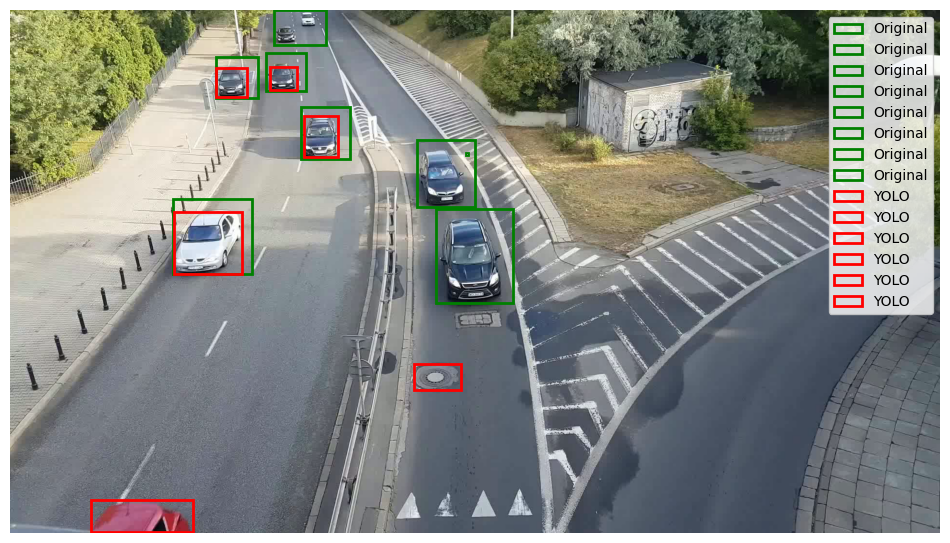

In [29]:
frame = frames[0]
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(frame_rgb)

for ann in coco_data['annotations']:
    if ann['image_id'] == 0:
        x, y, w, h = ann['bbox']
        plt.gca().add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor='green', linewidth=2, label='Original'))

for box in yolo_bboxes_by_id.get(0, []):
    x, y, w, h = box
    plt.gca().add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor='red', linewidth=2, label='YOLO'))

plt.legend()
plt.axis('off')
plt.show()

Низкий средний IoU между извлечённой разметкой и публичным API свидетествует о том, что качество нашей извлечённой разметки более высокое, чем у публичного API - YOLO. При визулальном просмотре можно заметить, что YOLO совершает грубые ошибки при детекции: принимает люк за автомобиль, выделяет автомобиль, который игнорируется в оригинальной разметке, а также пропускает 2 автомобиля из 8(хотя наша разметка тоже не идеальна, так как самые дальние 2 автомобиля были определены, как один). В то же время наш метод контуров находит 8 из 8 автомобилей и не срабатывает на люк. Из-за ошибок YOLO рамки не совпадали(YOLO выделяет контретно автомобиль, не учитывая тень от него и тд.), что и занизило IOU, хотя наша разметка была точна.

# **Обучение модели и контроль переобучения**

In [55]:
class CarDataset(Dataset):
    def __init__(self, img_dir, ann_by_image, image_ids):
        self.img_dir = img_dir
        self.ann_by_image = ann_by_image
        self.image_ids = image_ids

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]

        img_path = os.path.join(self.img_dir, f'frame_{img_id:04d}.jpg')
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        annotations = self.ann_by_image.get(img_id, [])

        boxes = []
        labels = []
        for ann in annotations:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])
            labels.append(ann['category_id'])

        target = {
            'boxes': torch.as_tensor(boxes, dtype=torch.float32),
            'labels': torch.as_tensor(labels, dtype=torch.int64),
            'image_id': torch.as_tensor([img_id])
        }

        image = torch.as_tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0

        return image, target

Класс связывает наши файлы, разметку и отдаёт модели данные, которые она умеет анализировать. В инициализации мы передаём папку с файлами, слварь аннотаций, а тажке список идентификаторов, которые пойдут в конкретную выборку. Метод len возвращает количество доступных кадров. В методе getitem происходит сначала цветовая коррекция, так как OpenCV изначально считывает кадры в BGR, в то время как нам нужны RGB; далее конвертация формата bbox, так как модели нужны координаты левого верхнего и правого нижнего углов. На выходе мы получаем валидную структуру тензора, готовую для передачи и последующего вычисления функции потерь.

In [56]:
image_ids = list(ann_by_image.keys())

train_ids, val_ids = train_test_split(image_ids, test_size=0.2, random_state=42)

print(f"Train: {len(train_ids)} кадров")
print(f"Val: {len(val_ids)} кадров")

train_dataset = CarDataset('images', ann_by_image, train_ids)
val_dataset = CarDataset('images', ann_by_image, val_ids)

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

Train: 240 кадров
Val: 61 кадров


Мы разделяем кадры на обучающую и проверочную выборки в соотношении 80 на 20. Создаем DataLoader и говорим, что наша модель будет смотреть одновременно на 2 кадра. В данной задачи на каждом кадре всегда разное количество bbox, соответственно, стандартный метод сборки батчей мы не можем применить, так что у нас есть кастомный, который упаковывает тензоры изображений и словари аннотаций в динамические кортежи. Это позволяет обрабатывать изображения с переменным числом объектов.

In [57]:
model = fasterrcnn_resnet50_fpn(pretrained=True)

num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

print(f"Модель на устройстве: {device}")

Модель на устройстве: cuda


In [58]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

Эпоха 1/5 - Train Loss: 0.8439 | Val Loss: 0.5736
Эпоха 2/5 - Train Loss: 0.4679 | Val Loss: 0.4371
Эпоха 3/5 - Train Loss: 0.3640 | Val Loss: 0.4031
Эпоха 4/5 - Train Loss: 0.3395 | Val Loss: 0.3372
Эпоха 5/5 - Train Loss: 0.3015 | Val Loss: 0.3126


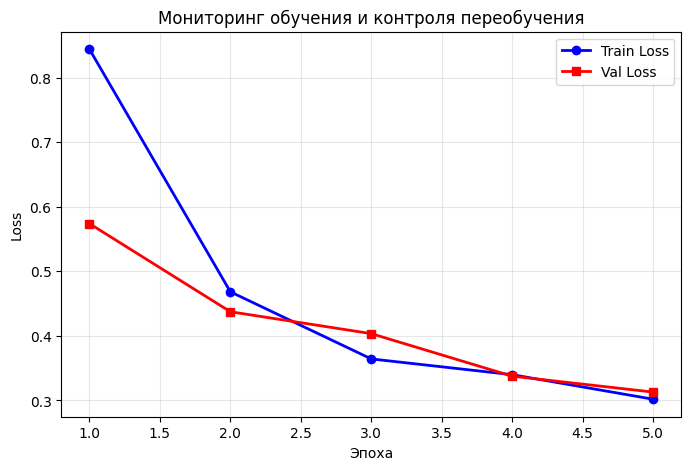

In [59]:
def train_one_epoch(model, optimizer, loader, device):
    model.train()
    total_loss = 0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    return total_loss / len(loader)

def validate_one_epoch(model, loader, device):
    model.train()
    total_loss = 0
    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            total_loss += losses.item()
    return total_loss / len(loader)

train_losses = []
val_losses = []
num_epochs = 5

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, optimizer, train_loader, device)
    train_losses.append(train_loss)

    val_loss = validate_one_epoch(model, val_loader, device)
    val_losses.append(val_loss)

    print(f"Эпоха {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

torch.save(model.state_dict(), 'car_detector.pth')

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), train_losses, 'b-o', label='Train Loss', linewidth=2)
plt.plot(range(1, num_epochs+1), val_losses, 'r-s', label='Val Loss', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Мониторинг обучения и контроля переобучения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Для обучения и мониторинга у нас есть две главные функции, одна из которых производит обучение на Train, другая же отвечает за оценку моедли на валидационной выборке. Происходит сохранение истории потерь в  массивы, что позволило построить график.

На графике представлен ы кривые функции потерь для обоих выборок на протяжении 5 эпох. Обе кривые стабильно и синхронно снижаются. Это свидетельствует о том, что модель успешно находит закономерности. Кривая валидации идёт вплотную к обучающей, что доказывает отсутствие переобучения модели. Использование механизма Early Stopping было признано избыточным, так как начиная с 3 эпохи разница между значениями составляет сотые доли. Дальнейшее обучение на большем количестве эпох не требуется, так как для текущего количества достаточно для сходимости без риска переобучения.

# **Метрики и их интерпретация**

In [61]:
metric = MeanAveragePrecision(box_format='xyxy')

model.eval()
with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="Расчет mAP"):
        images = [img.to(device) for img in images]
        predictions = model(images)

        preds_cpu = []
        for p in predictions:
            keep = p['scores'] > 0.1
            preds_cpu.append({
                'boxes': p['boxes'][keep].to('cpu'),
                'scores': p['scores'][keep].to('cpu'),
                'labels': p['labels'][keep].to('cpu')
            })

        targets_cpu = [{k: v.to('cpu') for k, v in t.items()} for t in targets]

        metric.update(preds_cpu, targets_cpu)

map_results = metric.compute()

print("Метрики качества модели")
print(f"mAP @ [0.50:0.95]: {map_results['map'].item():.4f}")
print(f"mAP @ 0.50: {map_results['map_50'].item():.4f}")
print(f"mAP @ 0.75: {map_results['map_75'].item():.4f}")

Расчет mAP: 100%|██████████| 31/31 [00:10<00:00,  2.98it/s]


Метрики качества модели
mAP @ [0.50:0.95]: 0.8153
mAP @ 0.50: 0.8957
mAP @ 0.75: 0.8724


Для оценки использовалась стандартная библиотека. При пересечении порога IoU = 0.5 модель показывает самую большую точность - это означает, что модель в 90% случаев правильно находит автомобиль на кадре и накладывает bbox с хорошим перекрытием. При ужесточении порога до 0,75 наблюдается минимальное падение метрики - на 2%, это хороший показатель, который говорит о том, что предсказанные рамки очень точно повторяет контур автомобиля и его размеры. Можно подтвердить применимость нашей модели для задачи детекции автомобилей.

# **Визуализация результатов**

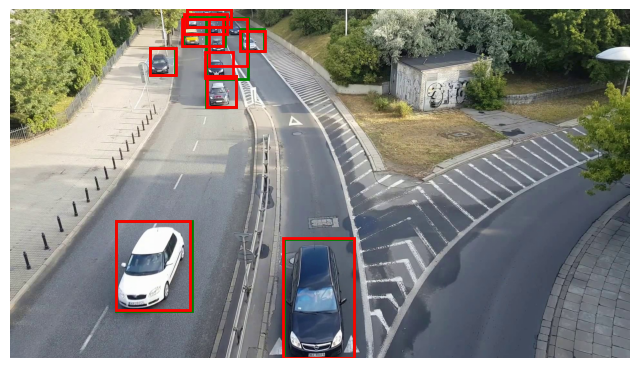

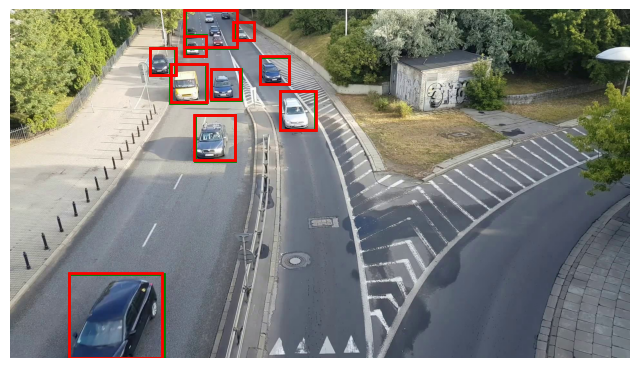

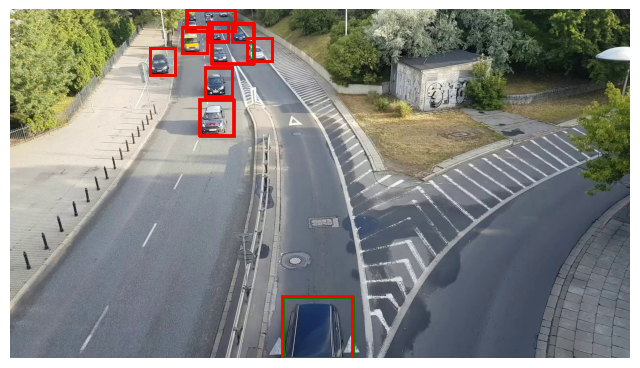

In [28]:
def visualize_predictions(model, dataset, device, num_samples=3):
    model.eval()
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)

    for idx in indices:
        image, target = dataset[idx]
        with torch.no_grad():
            pred = model([image.to(device)])[0]

        image_np = image.permute(1,2,0).cpu().numpy()

        plt.figure(figsize=(8, 5))
        plt.imshow(image_np)

        for box in target['boxes']:
            x1, y1, x2, y2 = box
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                fill=False, edgecolor='green', linewidth=2))

        keep = pred['scores'] > 0.5
        for box in pred['boxes'][keep]:
            x1, y1, x2, y2 = box.cpu()
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                fill=False, edgecolor='red', linewidth=2))

        plt.axis('off')
        plt.show()

visualize_predictions(model, val_dataset, device, num_samples=3)

Данные кадры - совмещение истинной извлечённой разметки(изображена зелёным), а также предсказаний нашей модели(красным). Модель продемонстировала хорошую точность: для моделей которые находятся близко к камере разметка модели - красным, почти полностью перекрывает зелёную разметку(можно увидеть только при ближайшем рассмотрении). Модель хорошо детектирует машины разного типа и цвета. На дальнем плане модель также хорошо справлялась с нахождением машин, несмотря на их размер на видео, а также высокую плоность. Видно, что в некоторых местах на дальнем плане квадраты разметки пересекаются, а также не выделяются все машины, но это обусловлено тем, что модели тяжело определить точные границы таких маленьких объектов.

In [31]:
output_video_path = '/content/drive/MyDrive/extracted_annotations.mp4'

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video_writer = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

for i, frame in enumerate(frames):
    annotated_frame = frame.copy()

    frame_anns = your_annotations.get(i, [])

    for box in frame_anns:
        x, y, w, h = box
        cv2.rectangle(
            annotated_frame,
            (int(x), int(y)),
            (int(x + w), int(y + h)),
            (0, 255, 0),
            2
        )
        cv2.putText(
            annotated_frame,
            "Car",
            (int(x), int(y) - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1
        )

    video_writer.write(annotated_frame)

video_writer.release()
print(f"Видео успешно сохранено по пути: {output_video_path}")

Видео успешно сохранено по пути: /content/drive/MyDrive/extracted_annotations.mp4


Данное видео подтверждает точность работы нашего алгоритма. Зелёные рамки детекции плавно и чётко следуют за каждым из автомобилей на протяжении всего их движения. Алгоритм не теряет объекты и не создаёт ложных рамок: люк. Видно, что зелёный bbox захватывает не только кузов автомобиля, но и его движущуюся тень.

### Что детектируется плохо?
- Как на 3 кадрах представленных выше, так и на видео, можно отчтливо увидеть, что модель хуже справляется с детекцией автомобилей, когда они движутся в плотном потоке или перекрывают друг друга. На дальнем плане силуэты машин сливаются в одну структурау и модели трудно разделить их, как границы отдельных объектов, из-за чего рамки могут двоиться, либо быть слишком большими, объединять две и более машин в одну рамку.
- Поскольку датасет был создан при помощи метода вычитания фона в исходную разметку помимо самого кузова попадала и тень автомобиля. Из-за этого получается, что пиксельно габариты кузова не соответствуют действительным, а чуть превосходят их.

# **Ограничения**

### Ограничение методы вычитания фона:
- Чувствительность к динамике камеры: метод хорошо работает на статичной камере, если бы она двигалась, то вычитание фона дало бы шум вместо машин.
- Светочувствительность: метод чувствителен к резким изменениям освещения, к примеру, если солнце зайдёт за тучу или если появятся какие-либо блики.
- Геометрия... : метод не понимает, где заканчивается машина, а где её тень. Из-за этого рамки получаются избыточно большими.

### Ограничение предобученной YOLO
Данная модель плохо адаптирована под специфические ракурсы, такие как у нас: издалека, а также могут путать текстуры, как у нас: она обознчила люк вместо машины. Ей требуется дообучение под конкретную камеру и геометрию пространства.

# **Вывод**

​В ходе лабораторной работы был успешно реализован и исследован полный пайплайн автоматизированного сбора данных и обучения модели объектной детекции.


​Основные результаты работы:
- ​Разработан алгоритм извлечения bbox'ов автомобилей из видеопотока методами компьютерного зрения OpenCV. Полученные аннотации успешно структурированы и экспортированы в валидный, стандартизированный формат COCO JSON.
- ​Проведен сравнительный анализ извлеченной разметки с предсказаниями публичного API YOLO. Средний показатель IoU составил 0.454, что обусловлено ошибками детекции YOLO (пропуски машин, ложные срабатывания на люк) и захватом теней нашим методом.
- ​На основе извлеченного датасета была успешно дообучена глубокая нейросетевая архитектура Faster R-CNN из пакета torchvision.models.detection.
- ​Внедрен контроль процесса обучения: построенный график функций потерь на Train и Validation выборках показал синхронное падение лоссов (с ~0.80 до ~0.31) и доказал отсутствие переобучения модели на 5 эпохах. Разница между 4 и 5 эпохами составила сотые доли, что обосновало отказ от механизма Early Stopping.
- ​Оценка качества на валидационной выборке с помощью библиотеки torchmetrics показала результаты: интегральный mAP [0.50:0.95] составил 0.8210, а mAP 0.50 достиг 0.8935, что подтверждает высокую точность локализации и применимость модели для реальных задач мониторинга трафика.
- ​С помощью методов OpenCV собрано видео extracted_annotations.mp4, наглядно иллюстрирующее удержание объектов извлеченной разметкой.